#Banking Loan Risk Analysis using Statistics, Probability & EDA

#use case

Exploratory Data Analysis and Statistical Insights for Loan Default Risk in Banking

#Objective

Students will learn how statistics, probability, and exploratory data analysis (EDA) are used in real banking analytics to understand loan risk, customer behavior, and financial patterns.

#Tools Used:

NumPy – synthetic data generation

Pandas – data manipulation and analysis

Matplotlib / Seaborn – data visualization

SciPy – statistical testing

#Scenario

A bank wants to analyze its loan portfolio to answer the following questions:

> What is the probability of loan default?

> Which loan types are riskier?

> Does customer income influence loan amount?

> Do different loan categories have different loan values?

> Are there relationships between financial variables?

Students will analyze a synthetic dataset of 200 banking customers.

#Step 1: Dataset Creation



In [16]:
import pandas as pd # Import the pandas library for data manipulation and analysis
import numpy as np # Import the numpy library for numerical operations, especially for generating synthetic data

np.random.seed(42) # Set the random seed for reproducibility of the generated data

data = { # Define a dictionary to store the data for the DataFrame
    "Customer_ID": range(1,201), # Create Customer IDs from 1 to 200
    "Loan_Type": np.random.choice(["Home Loan","Personal Loan","Car Loan"],200), # Randomly assign one of three loan types to 200 customers
    "Default": np.random.choice(["Yes","No"],200,p=[0.25,0.75]), # Randomly assign "Yes" or "No" for default status with a 25% default probability
    "Income": np.random.normal(60000,15000,200), # Generate 200 random income values from a normal distribution (mean=60000, std=15000)
    "Loan_Amount": np.random.normal(250000,50000,200), # Generate 200 random loan amount values from a normal distribution (mean=250000, std=50000)
    "Credit_Score": np.random.normal(700,50,200) # Generate 200 random credit score values from a normal distribution (mean=700, std=50)
}

df = pd.DataFrame(data) # Create a pandas DataFrame from the dictionary
df.head() # Display the first 5 rows of the DataFrame

,Customer_ID,Loan_Type,Default,Income,Loan_Amount,Credit_Score
0,1,Car Loan,No,70486.385728,367098.760126,813.832581
1,2,Home Loan,Yes,68998.449506,194907.260001,618.534869
2,3,Car Loan,No,52781.277993,330589.638286,705.492647
3,4,Car Loan,Yes,28593.089939,209352.222594,756.482474
4,5,Home Loan,No,53699.288031,278011.285549,671.084304


#Activity 1: Basic Data Exploration

Students explore dataset structure.



In [17]:
df.info() # Print a concise summary of the DataFrame, including data types and non-null values
df.describe() # Generate descriptive statistics of the DataFrame's numerical columns
df.isnull().sum() # Calculate the sum of null values for each column in the DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Customer_ID   200 non-null    int64  
 1   Loan_Type     200 non-null    object 
 2   Default       200 non-null    object 
 3   Income        200 non-null    float64
 4   Loan_Amount   200 non-null    float64
 5   Credit_Score  200 non-null    float64
dtypes: float64(3), int64(1), object(2)
memory usage: 9.5+ KB


,0
Customer_ID,0
Loan_Type,0
Default,0
Income,0
Loan_Amount,0
Credit_Score,0


#Learning

Understand:

>data types

>statistical summary

> missing values

#Activity 2: Distribution Analysis (Histogram)
#Business Question

How is customer income distributed?

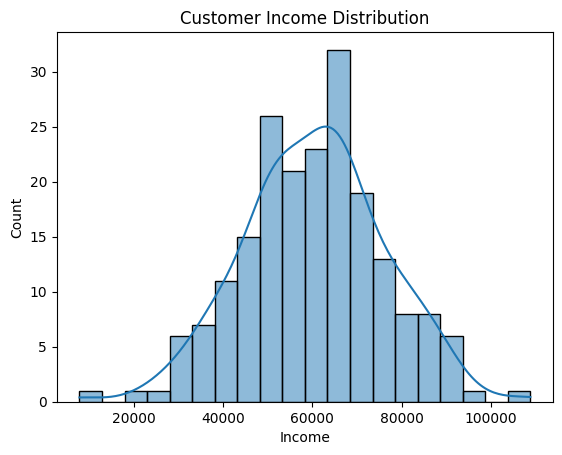

In [18]:
import seaborn as sns # Import the seaborn library for statistical data visualization
import matplotlib.pyplot as plt # Import the matplotlib.pyplot module for plotting

sns.histplot(df["Income"], bins=20, kde=True) # Create a histogram of the 'Income' column with 20 bins and a Kernel Density Estimate (KDE)
plt.title("Customer Income Distribution") # Set the title of the plot
plt.show() # Display the plot

#Insight

Detect:

>distribution shape

>skewness

>outliers

#Activity 3: Loan Type Distribution (Bar Chart)
Question

Which loan type is most common?

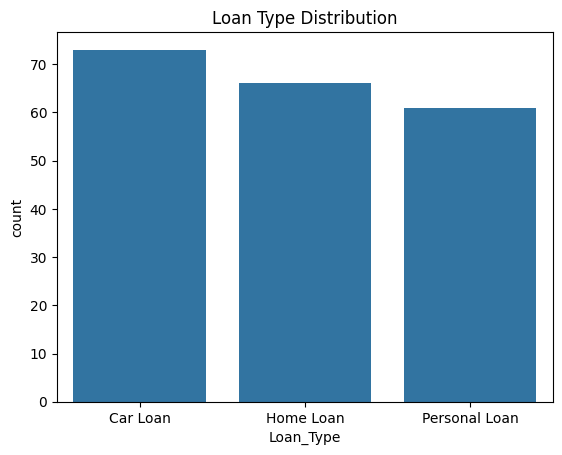

In [19]:
sns.countplot(x="Loan_Type", data=df) # Create a bar plot showing the count of each 'Loan_Type'
plt.title("Loan Type Distribution") # Set the title of the plot
plt.show() # Display the plot

**Insight**

Identify most popular banking products.

#Activity 4: Default Rate Visualization



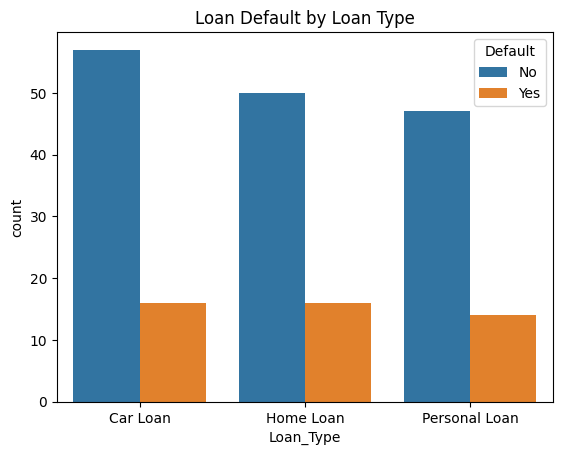

In [20]:
sns.countplot(x="Loan_Type", hue="Default", data=df) # Create a bar plot showing the count of each 'Loan_Type', separated by 'Default' status
plt.title("Loan Default by Loan Type") # Set the title of the plot
plt.show() # Display the plot

**Insight**

Detect riskier loan categories.

#Activity 5: Central Tendency Analysis

In [21]:
df[["Income","Loan_Amount"]].mean() # Calculate the mean of 'Income' and 'Loan_Amount' columns
df[["Income","Loan_Amount"]].median() # Calculate the median of 'Income' and 'Loan_Amount' columns

,0
Income,61296.022671
Loan_Amount,258441.545787


**Insight**

Identify typical borrower profile.

#Activity 6: Dispersion Analysis

In [22]:
df["Loan_Amount"].std() # Calculate the standard deviation of the 'Loan_Amount' column
df["Loan_Amount"].var() # Calculate the variance of the 'Loan_Amount' column

3033385224.7421126

**Insight**

Understand spread of loan amounts.

#Activity 7: Probability of Default

In [23]:
default_prob = (df["Default"]=="Yes").mean() # Calculate the proportion of 'Yes' in the 'Default' column to get the probability of default
print(default_prob) # Print the calculated probability of default

0.23


#Visualization

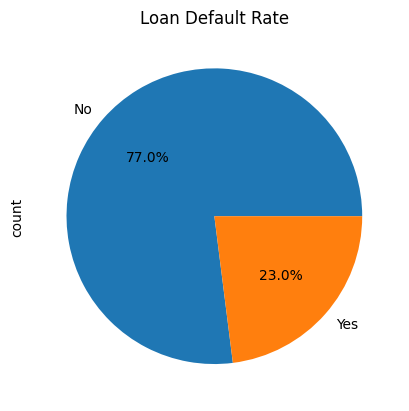

In [24]:
df["Default"].value_counts().plot.pie(autopct="%1.1f%%") # Create a pie chart showing the proportion of 'Default' values, with percentages displayed
plt.title("Loan Default Rate") # Set the title of the plot
plt.show() # Display the plot

**Banking Impact**

Helps estimate portfolio risk level.

#Activity 8: Scatter Plot Relationship
Question

Does income influence loan amount?

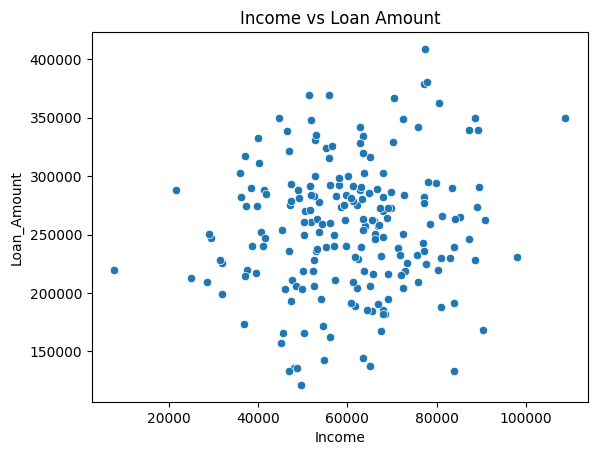

In [25]:
sns.scatterplot(x="Income", y="Loan_Amount", data=df) # Create a scatter plot of 'Income' vs 'Loan_Amount'
plt.title("Income vs Loan Amount") # Set the title of the plot
plt.show() # Display the plot

**Insight**

Understand financial behavior patterns.

#Activity 9: Correlation Analysis

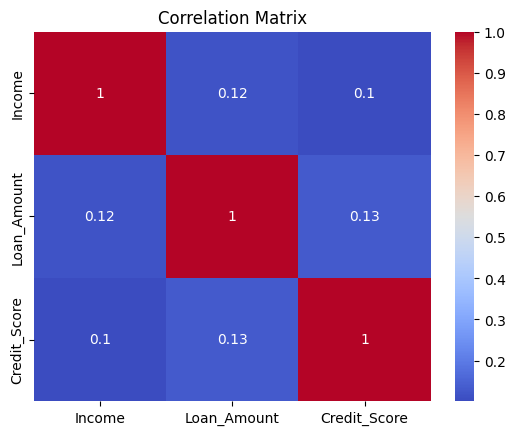

In [26]:
sns.heatmap(df[["Income","Loan_Amount","Credit_Score"]].corr(), # Create a heatmap of the correlation matrix for selected numerical columns
            annot=True, cmap="coolwarm") # Annotate the heatmap with correlation values and use the 'coolwarm' colormap
plt.title("Correlation Matrix") # Set the title of the plot
plt.show() # Display the plot

**Insight**

Detect relationships between financial variables.

#Activity 10: Box Plot (Outlier Detection)

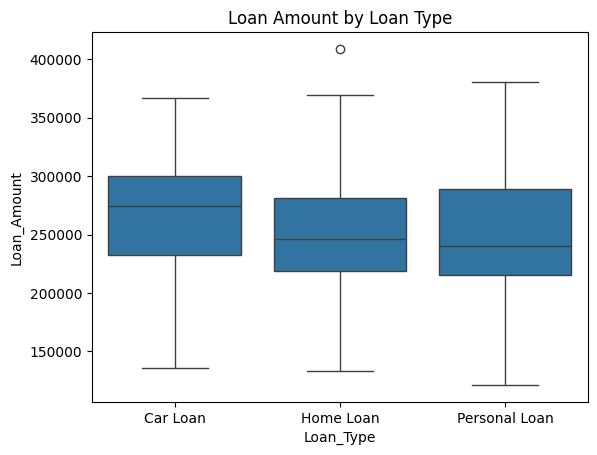

In [27]:
sns.boxplot(x="Loan_Type", y="Loan_Amount", data=df) # Create a box plot to visualize 'Loan_Amount' distribution across different 'Loan_Type'
plt.title("Loan Amount by Loan Type") # Set the title of the plot
plt.show() # Display the plot

#Insight

Compare loan amount variation across categories.

#Activity 11: Hypothesis Testing Framework
**Business Question**

Does loan type influence default risk?

**Define hypotheses:**

H₀: Loan type does not affect default

H₁: Loan type affects default

#Activity 12: Chi-Square Test

In [28]:
from scipy.stats import chi2_contingency # Import chi2_contingency function from scipy.stats for chi-square test

table = pd.crosstab(df["Loan_Type"],df["Default"]) # Create a contingency table between 'Loan_Type' and 'Default'
chi2,p,dof,expected = chi2_contingency(table) # Perform the chi-square test and store the chi2 statistic, p-value, degrees of freedom, and expected frequencies

print(p) # Print the p-value from the chi-square test

0.9484353105002302


**Interpretation**

If p < 0.05

Loan type significantly influences default risk.

#Activity 13: ANOVA Test
**Question**

Do loan types differ in average loan amount?

In [29]:
from scipy.stats import f_oneway # Import f_oneway function from scipy.stats for one-way ANOVA

home = df[df["Loan_Type"]=="Home Loan"]["Loan_Amount"] # Filter 'Loan_Amount' for 'Home Loan'
personal = df[df["Loan_Type"]=="Personal Loan"]["Loan_Amount"] # Filter 'Loan_Amount' for 'Personal Loan'
car = df[df["Loan_Type"]=="Car Loan"]["Loan_Amount"] # Filter 'Loan_Amount' for 'Car Loan'

f_stat,p_value = f_oneway(home,personal,car) # Perform one-way ANOVA on loan amounts for different loan types

print(p_value) # Print the p-value from the ANOVA test

0.07382864891553911


**Insight**

If p < 0.05

Loan types differ significantly in loan value.

#Activity 14: Credit Score vs Default (Violin Plot)

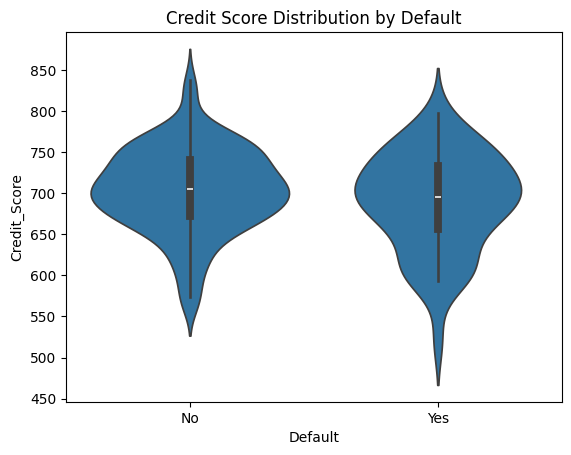

In [30]:
sns.violinplot(x="Default", y="Credit_Score", data=df) # Create a violin plot to show the distribution of 'Credit_Score' for each 'Default' status
plt.title("Credit Score Distribution by Default") # Set the title of the plot
plt.show() # Display the plot

**Insight**

Lower credit score customers may show higher default risk.

#Final Student Challenge

Students must create 3 additional charts and explain insights.

Examples:

> Credit score distribution

> Average income by loan type

>Loan amount vs credit score scatter plot

#Key Learning Outcomes

Students understand:

>Data exploration before modeling

>Probability in financial risk estimation

>Distribution analysis and outlier detection

>Correlation and feature relationships

>Hypothesis testing in business analytics

> Visualization techniques for financial insights